# Comparison of different power flow algorithms

A minimal example to demonstrate the effect of different algorithms on calculations. 
This is not meant to be a comprehensive comparison of algorithms, but rather a demonstration of how different algorithms can give different results and how to interpret those results.

Import required things

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from power_grid_model import ComponentType, DatasetType, PowerGridModel, initialize_array, LoadGenType, CalculationMethod
%matplotlib inline

We can run this simulation for a range of p_specified and q_specified values. The range is mentioned here.
The characteristics of the results are very situational and depend on the system and the range of values as well as grid configuration and parameters.

In [2]:
RESOLUTION = 1000
P_SPECIFIED = 1e8 * np.linspace(-1, 1, RESOLUTION)
Q_SPECIFIED = P_SPECIFIED * np.tan(np.arccos(0.95))

## Minimal Grid


```{r}
source --------------  node -------------- line -------------- node --------------- sym_load
(u_ref)                                                                             (p_load, q_load)
```


In [3]:

nodes = initialize_array(DatasetType.input, ComponentType.node, 2)
nodes["id"] = [0, 1]
nodes["u_rated"] = [1e4, 1e4]

lines = initialize_array(DatasetType.input, ComponentType.line, 1)
lines["id"] = [2]
lines["from_node"] = [0]
lines["to_node"] = [1]
lines["from_status"] = [1]
lines["to_status"] = [1]
lines["r1"] = [1]
lines["x1"] = [2]
lines["c1"] = [1e-8]
lines["tan1"] = [0.0]
lines["i_n"] = [500.0]

sym_loads = initialize_array(DatasetType.input, ComponentType.sym_load, 1)
sym_loads["id"] = [3]
sym_loads["node"] = [1]
sym_loads["status"] = [1]
sym_loads["type"] = [LoadGenType.const_power]
sym_loads["p_specified"] = [1e6]
sym_loads["q_specified"] = [1e6 * np.tan(np.arccos(0.9))]

sources = initialize_array(DatasetType.input, ComponentType.source, 1)
sources["id"] = [4]
sources["node"] = [0]
sources["status"] = [1]
sources["u_ref"] = [1.0]
sources["u_ref_angle"] = [0.0]

input_data_pf = {"node": nodes, "line": lines, "sym_load": sym_loads, "source": sources}

model = PowerGridModel(input_data_pf)


## Power flow run

`u_ref` is fixed at 1.p.u. while we try to vary `p_specified` and `q_specified`.

In [4]:
sym_load_update = initialize_array(DatasetType.update, ComponentType.sym_load, (1000, 1))
sym_load_update["id"] = [3]
sym_load_update["p_specified"] = P_SPECIFIED.reshape(-1, 1)
sym_load_update["q_specified"] = Q_SPECIFIED.reshape(-1, 1)
update_data_pf = {"sym_load": sym_load_update}

results_pf_lc = model.calculate_power_flow(update_data=update_data_pf, calculation_method=CalculationMethod.linear_current)
results_pf_lz = model.calculate_power_flow(update_data=update_data_pf, calculation_method=CalculationMethod.linear)

results_pf_nr = model.calculate_power_flow(update_data=update_data_pf, calculation_method=CalculationMethod.newton_raphson, continue_on_batch_error=True)

# Impute failed scenarios with NaN
fail_mask = np.zeros(1000, dtype=bool)
if model.batch_error is not None:
    fail_mask[model.batch_error.failed_scenarios] = True
    for comp_name, arr in results_pf_nr.items():
        results_pf_nr[comp_name][fail_mask] = initialize_array(DatasetType.sym_output, comp_name, 1)

    print(f"Number of failed scenarios: {len(model.batch_error.failed_scenarios)}")

Number of failed scenarios: 583


### Nodal voltage and line loading

As the grid is loaded, the voltages deviate from 1 p.u. The newton raphson results are the actual voltages for the given calculations, while linear/linear current algorithms are approximations. 
These approximation algorithms are suitable around 1 p.u. neighbourhood where the error in voltages due to approximation is minimum. The approximation errors get much larger outside of this neighbourhood.
It is also observed that the linear current method gives much worse results at very high loading compared to linear method.

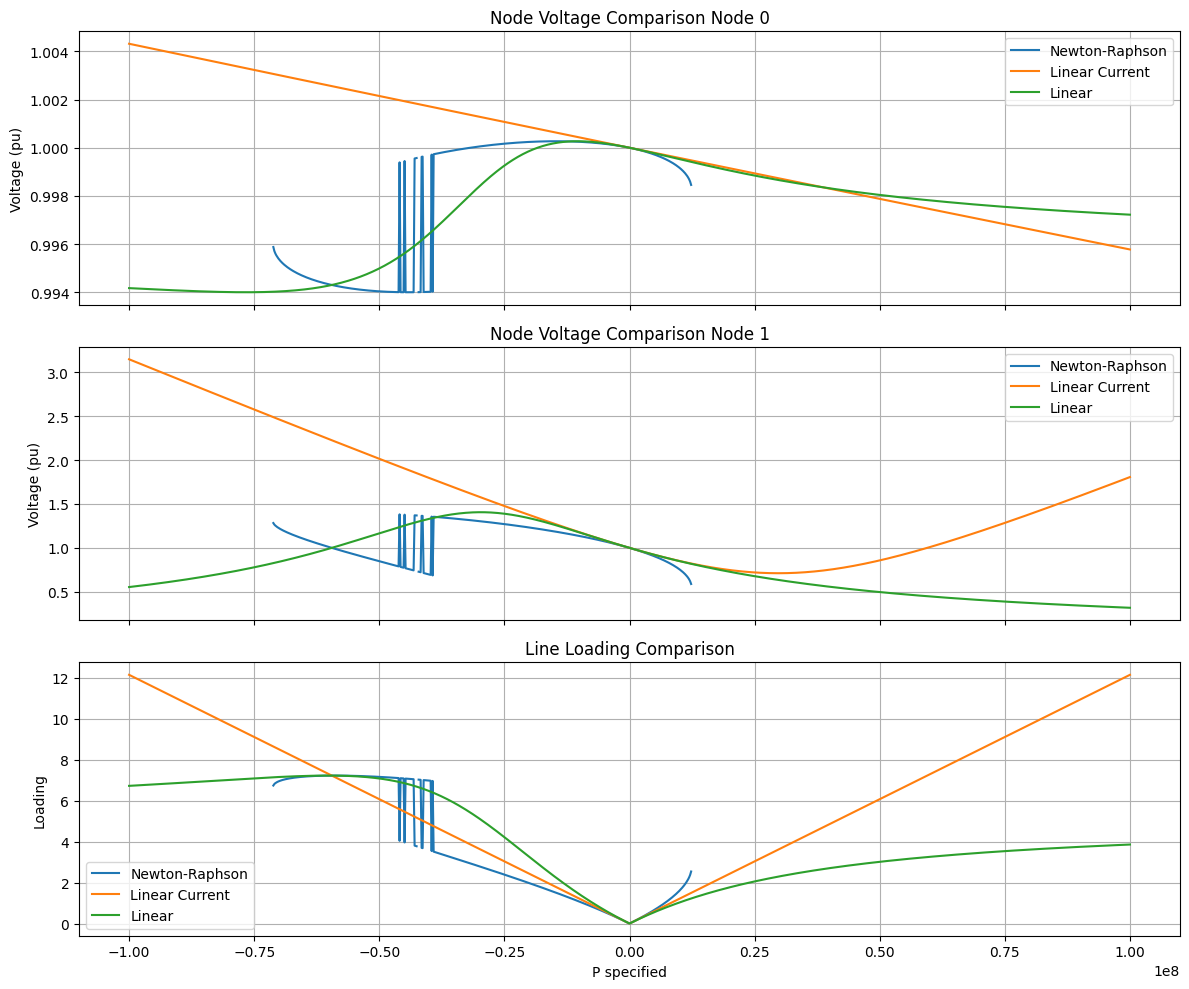

In [5]:
# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(12, 10))

# Plot Node Voltage Comparison Node 0
ax1.plot(P_SPECIFIED, results_pf_nr["node"]["u_pu"][:,0], label="Newton-Raphson")
ax1.plot(P_SPECIFIED, results_pf_lc["node"]["u_pu"][:,0], label="Linear Current")
ax1.plot(P_SPECIFIED, results_pf_lz["node"]["u_pu"][:,0], label="Linear")
ax1.set(ylabel="Voltage (pu)", title="Node Voltage Comparison Node 0")
ax1.grid()
ax1.legend()

# Plot Node Voltage Comparison Node 1
ax2.plot(P_SPECIFIED, results_pf_nr["node"]["u_pu"][:,1], label="Newton-Raphson")
ax2.plot(P_SPECIFIED, results_pf_lc["node"]["u_pu"][:,1], label="Linear Current")
ax2.plot(P_SPECIFIED, results_pf_lz["node"]["u_pu"][:,1], label="Linear")
ax2.set(ylabel="Voltage (pu)", title="Node Voltage Comparison Node 1")
ax2.grid()
ax2.legend()

# Plot Line Loading Comparison
ax3.plot(P_SPECIFIED, results_pf_nr["line"]["loading"][:, 0], label="Newton-Raphson")
ax3.plot(P_SPECIFIED, results_pf_lc["line"]["loading"][:, 0], label="Linear Current")
ax3.plot(P_SPECIFIED, results_pf_lz["line"]["loading"][:, 0], label="Linear")
ax3.set(xlabel="P specified", ylabel="Loading", title="Line Loading Comparison")
ax3.grid()
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

## Specified power vs actual power

Another way of looking at this is from the injected power side. We can see that linear algorithm outputs loadgen power to be different than what is assumed for constant power / constant current load type. This output is a posteriori view of the p_specified / q_specified as per the result of the algorithm. It can be an indicator of how incorrect the algorithm would be. If `p=p_specified` and `q=q_specified`, the approximation is the same as actual result. If its further away from this line, then the results are more inaccurate. 

**Note: This output does not have a posteriori view with linear current but it has a different behavior. Hence the same logic as mentioned here does not apply to this method.**

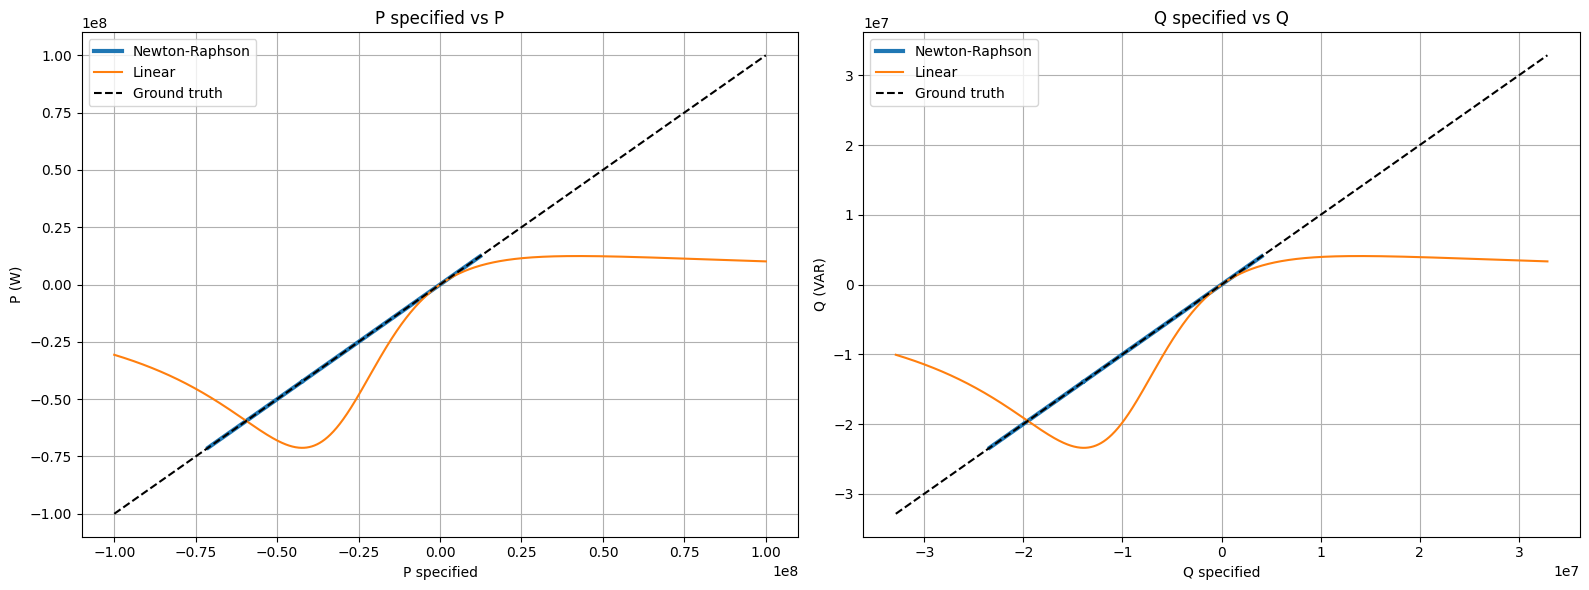

In [6]:
# Create subplots
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(16, 6))

ax2.plot(P_SPECIFIED, results_pf_nr["sym_load"]["p"][:, 0], linewidth=3.0, label='Newton-Raphson')
ax2.plot(P_SPECIFIED, results_pf_lz["sym_load"]["p"][:, 0], label='Linear')

ax2.plot(P_SPECIFIED, P_SPECIFIED, 'k--', label='Ground truth')
ax2.set(xlabel='P specified', ylabel='P (W)', title='P specified vs P')
ax2.grid()
ax2.legend()

ax3.plot(Q_SPECIFIED, results_pf_nr["sym_load"]["q"][:, 0], linewidth=3.0, label='Newton-Raphson')
ax3.plot(Q_SPECIFIED, results_pf_lz["sym_load"]["q"][:, 0], label='Linear')

ax3.plot(Q_SPECIFIED, Q_SPECIFIED, 'k--', label='Ground truth')
ax3.set(xlabel='Q specified', ylabel='Q (VAR)', title='Q specified vs Q')
ax3.grid()
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Conclusions

- Newton Raphson and iterative current methods give all correct results.
- Newton Raphson is very stable around 1 p.u. region, but can give iteration diverges in a region away from it. The iteration diverge can be because of no practical solution by the non linearity of system or perhaps failure of algorithm to find the solution. These iteration diverges can be a good indicator of the former case which are often more likely than latter.
- Linear and Linear current are approximations of the power flow and their error varies proportionally to the nodal voltages.
- The linear current method would have better results compared to linear if the majority of the load is of constant power / constant current. The linear method would have better results compared to linear current if the majority of loads are of constant impedance.
- Capacity calculations like loading can be affected by some amount at voltages away from 1 p.u.
- The effect of higher loading plateaus off at approximation methods.

## Tips
- If one is to use the approximation algorithms, it is good to look at the ranges of the output voltage. If they are far from 1 p.u., their results would need to be scrutinized.